# 9)
## i)
Since $X_k \sim max(Y_1, Y_2, ..., Y_k) - log(k)$, where $Y_i \sim exp(\lambda)$ then we have
$$
P(X_k \leq x) = P(max(Y_1, Y_2, ..., Y_k) - log(k) \leq x) = P(max(Y_1, Y_2, ..., Y_k) \leq x + log(k))$$
The max can be transformed into the condition that $Y_1 \leq x + log(k) \cap Y_2 \leq x + log(k) ... \cap Y_k \leq x + log(k)$, thus
$$
P(X_k \leq x) = P(Y_1 \leq x + log(k) \cap Y_2 \leq x + log(k) ... \cap Y_k \leq x + log(k)).
$$
Since the $Y_i$'s are independent, we can write this as the product of the individual probabilities,
$$
P(X_k \leq x) = P(Y_1 \leq x + log(k)) P(Y_2 \leq x + log(k)) ... P(Y_k \leq x + log(k)) = P(Y_1 \leq x + log(k))^k
$$
Note that we then get the $k$th power of the CDF of the exponential distribution, which is given by
$$
F_Y(y) = 1 - e^{-\lambda y}.
$$
As such, we have
$$
P(X_k \leq x) = (1 - e^{-\lambda (x + log(k))})^k
$$
Using the exponential product rule and the fact that $e^{log(k)} = k$, we can write this as
$$
P(X_k \leq x) = (1 - e^{-\lambda x} e^{-\lambda log(k)})^k = (1 - e^{-\lambda x} k^{-\lambda})^k
$$

We can now use the analysis result that $\lim_{k \to \infty} (1 - \frac{a}{k})^k = e^{-a}.$ If we let $a = e^{-\lambda x}k^{1-\lambda}$, then we have $\dfrac{a}{k} = e^{-\lambda x}k^{-\lambda}$ and thus we get
$$
\lim_{k \to \infty} P(X_k \leq x) = e^{-e^{-\lambda x}k^{1-\lambda}}
$$
Thus for a standard exponential distribution with $\lambda = 1$, we have
$$
\lim_{k \to \infty} P(X_k \leq x) = e^{-e^{-x}} = F_G(x)
$$
## ii)
We can use the inverse transform method to generate samples from the Gumbel distribution. The inverse CDF of the Gumbel distribution is given by
$$
y = e^{-e^{-x}} \iff log(y) = -e^{-x} \iff -log(y) = e^{-x} \iff log(-log(y)) = -x \iff x = -log(-log(y))
$$
so
$$
F_G^{-1}(x) = -log(-log(x))
$$
We can then apply proposition 2.1.

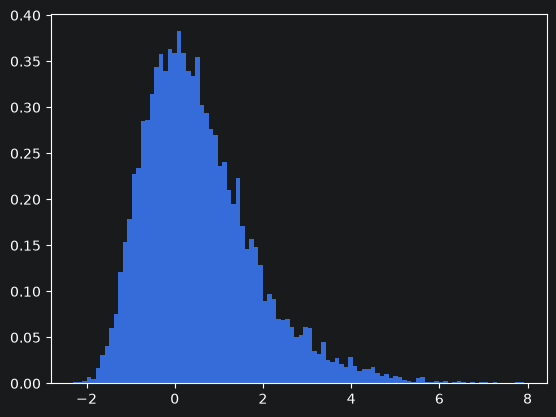

In [39]:
import numpy as np
import matplotlib.pyplot as plt
def rGumbel(n):
    # Inverse transform method to generate n samples from the STANDARD Gumbel distribution
    u = np.random.uniform(0, 1, n)
    inverse = lambda x: -np.log(-np.log(x))
    x = inverse(u)
    return x
N = 10000
g = rGumbel(N)
plt.hist(g, bins=100, density=True)
plt.show()

## iii)
We can check if the empirical CDF of the generated samples converges to the analytical CDF of the Gumbel distribution. We can plot both the empirical and analytical CDFs for comparison.

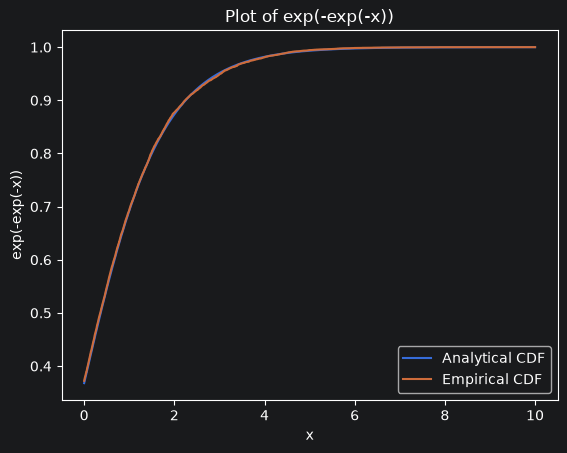

In [40]:
# plots of exp(-exp(-x)) for x in [0, 10] and the empirical cdf
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 10, N)
y = lambda x: np.exp(-np.exp(-x))
emp = lambda N, x, g: np.array([np.sum(g <= xi) / N for xi in x])
plt.plot(x, y(x), label = "Analytical CDF")
plt.plot(x, emp(N,x, g), label = "Empirical CDF")
plt.title("Plot of exp(-exp(-x))")
plt.xlabel("x")
plt.ylabel("exp(-exp(-x))")
plt.legend()


## iiii)
One more way to check the convergence is to use the Kolmogrov Distance:
$$
D_k = \sup_x |F_n(x) - F(x)|
$$
Which we can estimate by taking the maximum of the absolute difference between the empirical and analytical CDFs.


Text(0, 0.5, 'Kolmogorov Distance')

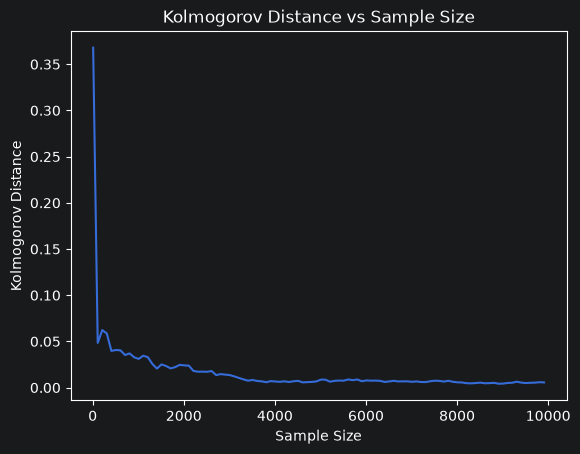

In [41]:
def kolmogorov_distance(empirical_cdf, analytical_cdf):
    return np.max(np.abs(empirical_cdf - analytical_cdf))
Ns = range(10, 10000, 100)
distances = []
for N in Ns:
    g_k = g[0:N]
    x = np.linspace(0, 10, N)
    empirical_cdf = emp(N, x, g_k)
    analytical_cdf = y(x)
    d_k = kolmogorov_distance(empirical_cdf, analytical_cdf)
    distances.append(d_k)

plt.plot(Ns, distances)
plt.title("Kolmogorov Distance vs Sample Size")
plt.xlabel("Sample Size")
plt.ylabel("Kolmogorov Distance")
